   Month_No  Predicted_Sales
0        13     33530.303030
1        14     35355.477855
2        15     37180.652681
3        16     39005.827506
4        17     40831.002331
5        18     42656.177156


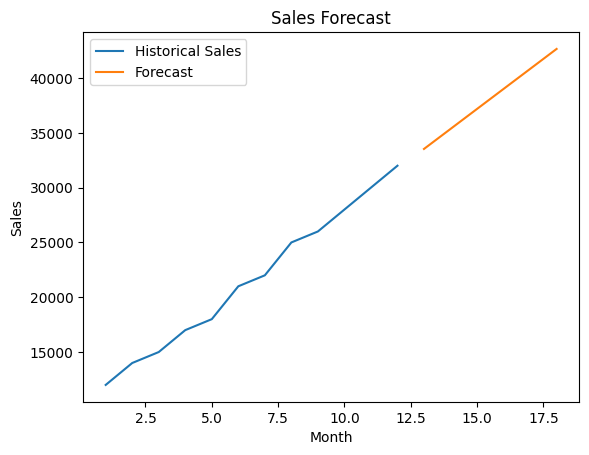

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("sales_forecast.csv")

df['Month_No'] = range(1, len(df)+1)

X = df[['Month_No']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

future_months = pd.DataFrame({
    'Month_No':[13,14,15,16,17,18]
})

predictions = model.predict(future_months)

future_df = pd.DataFrame({
    'Month_No':[13,14,15,16,17,18],
    'Predicted_Sales':predictions
})

print(future_df)

plt.plot(df['Month_No'],df['Sales'],label='Historical Sales')
plt.plot(future_df['Month_No'],
         future_df['Predicted_Sales'],
         label='Forecast')

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Forecast')
plt.legend()
plt.show()

future_df.to_csv("forecast_output.csv",index=False)

In [2]:
from sklearn.metrics import r2_score

pred = model.predict(X)

print("R2 Score:",r2_score(y,pred))

R2 Score: 0.9952032647018719
